<a href="https://colab.research.google.com/github/ashtonefrazier2424/ThinkPythonAssignments2026/blob/main/Week15_2/Week15_DreamProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit
Choose an option: 4
Enter year: 2026
How many books do you want to read? 65
🎯 Goal saved!

--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit
Choose an option: 1
Title: Death on the Nile
Author: Agatha Christie
Genre: Mystery
Pages: 350
Start date (YYYY-MM-DD): 2026-03-15
End date (YYYY-MM-DD): 2026-03-18
Rating (1-5): 5
✅ Book added!


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit
Choose an option: 1
Title: Salem's Lot
Author: Stephen King
Genre: Horror
Pages: 450
Start date (YYYY-MM-DD): 2026-01-23
End date (YYYY-MM-DD): 2026-01-27
Rating (1-5): 4
✅ Book added!


--- Reading Tracker ---
1. Add Book
2. View Stats
3. 

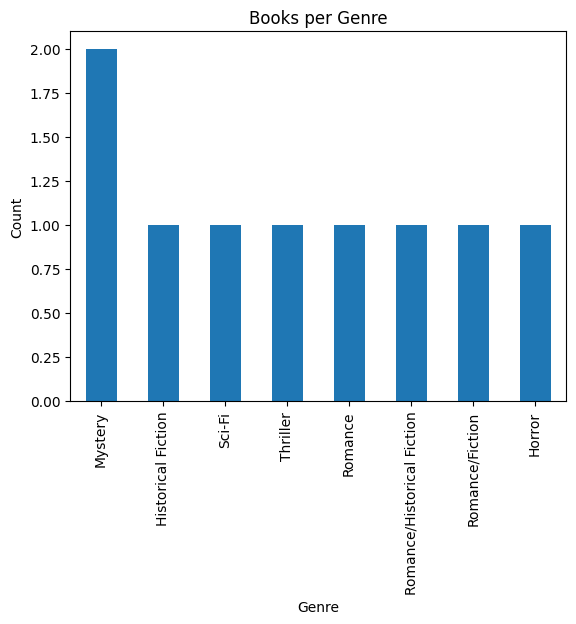


--- Reading Tracker ---
1. Add Book
2. View Stats
3. Recommend Books
4. Set Reading Goal
5. View Progress
6. Exit


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

conn = sqlite3.connect("/content/drive/MyDrive/reading_tracker.db")
cursor = conn.cursor()

# Install libraries (only needed in Colab)
!pip install pandas matplotlib

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Connect to database (creates file)
conn = sqlite3.connect("reading_tracker.db")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS books (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT,
    author TEXT,
    genre TEXT,
    pages INTEGER,
    start_date TEXT,
    end_date TEXT,
    rating REAL
)
""")
conn.commit()

cursor.execute("""
CREATE TABLE IF NOT EXISTS goals (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    target_books INTEGER,
    year INTEGER
)
""")
conn.commit()


# -------- ADD BOOK FUNCTION --------
def add_book():
    title = input("Title: ")
    author = input("Author: ")
    genre = input("Genre: ")
    pages = int(input("Pages: "))
    start_date = input("Start date (YYYY-MM-DD): ")
    end_date = input("End date (YYYY-MM-DD): ")
    rating = float(input("Rating (1-5): "))

    cursor.execute("""
    INSERT INTO books (title, author, genre, pages, start_date, end_date, rating)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (title, author, genre, pages, start_date, end_date, rating))

    conn.commit()
    print("✅ Book added!\n")


# -------- VIEW STATS FUNCTION --------
def view_stats():
    df = pd.read_sql_query("SELECT * FROM books", conn)

    if df.empty:
        print("No data yet.")
        return

    total_pages = df["pages"].sum()
    avg_rating = df["rating"].mean()

    # Calculate reading speed
    df["start_date"] = pd.to_datetime(df["start_date"])
    df["end_date"] = pd.to_datetime(df["end_date"])
    df["days"] = (df["end_date"] - df["start_date"]).dt.days + 1
    df["speed"] = df["pages"] / df["days"]

    avg_speed = df["speed"].mean()

    print("\n📊 Reading Stats:")
    print(f"Total pages read: {total_pages}")
    print(f"Average rating: {avg_rating:.2f}")
    print(f"Average reading speed (pages/day): {avg_speed:.2f}")

    # Genre count chart
    genre_counts = df["genre"].value_counts()

    genre_counts.plot(kind='bar')
    plt.title("Books per Genre")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.show()

def recommend_books():
    df = pd.read_sql_query("SELECT * FROM books", conn)

    if df.empty:
        print("No data yet.")
        return

    # Focus on highly rated books
    liked = df[df["rating"] >= 4]

    if liked.empty:
        print("Add some highly rated books first!")
        return

    top_genres = liked["genre"].value_counts().head(3)

    print("\n📚 Recommended Genres Based on Your Taste:")
    for genre in top_genres.index:
        print(f"- Try more {genre} books!")

    print("\n💡 Tip: Look for books in these genres online or expand this with an API later.")


def set_goal():
    year = int(input("Enter year: "))
    target = int(input("How many books do you want to read? "))

    cursor.execute("INSERT INTO goals (target_books, year) VALUES (?, ?)", (target, year))
    conn.commit()

    print("🎯 Goal saved!")

def view_progress():
    df = pd.read_sql_query("SELECT * FROM books", conn)
    goals = pd.read_sql_query("SELECT * FROM goals ORDER BY id DESC LIMIT 1", conn)

    if goals.empty:
        print("No goal set yet.")
        return

    goal = goals.iloc[0]["target_books"]
    year = goals.iloc[0]["year"]

    df["end_date"] = pd.to_datetime(df["end_date"])
    df_year = df[df["end_date"].dt.year == year]

    books_read = len(df_year)

    progress = (books_read / goal) * 100 if goal > 0 else 0

    print(f"\n📈 Progress for {year}:")
    print(f"Books read: {books_read}/{goal}")
    print(f"Progress: {progress:.2f}%")

    remaining = goal - books_read
    print(f"Books remaining: {max(0, remaining)}")

# -------- MAIN MENU --------
def menu():
    while True:
        print("\n--- Reading Tracker ---")
        print("1. Add Book")
        print("2. View Stats")
        print("3. Recommend Books")
        print("4. Set Reading Goal")
        print("5. View Progress")
        print("6. Exit")

        choice = input("Choose an option: ")

        if choice == "1":
            add_book()
        elif choice == "2":
            view_stats()
        elif choice == "3":
            recommend_books()
        elif choice == "4":
            set_goal()
        elif choice == "5":
            view_progress()
        elif choice == "6":
            print("Goodbye!")
            break
        else:
            print("Invalid choice.")

menu()